In [1]:
!pip install skimpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.1 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: ipykernel
    Found existing installation: ipykernel 6.17.1
    Uninstalling ipykernel-6.17.1:
      Successfully uninstalled ipykernel-6.17.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipykernel==6.17.1, but you have ipykernel 6.29.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible

In [2]:
import numpy as np
import pandas as pd
from skimpy import skim
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from matplotlib import pyplot as plt

In [3]:
countries_ue = pd.read_csv('/content/drive/MyDrive/00_datamining/countries_ue.txt', sep = '\t')

In [4]:
countries_ue.shape

(27, 13)

In [5]:
countries_ue.head()

,Pays,PIB,Dep_pub,Rev_net,Esp_vie,Chomage,Education,Gini,Securite,Adhesion,OCDE,Localisation,Rating
0,BE,32700.0,17187.5,20.8,80.3,8.3,30.0,26.6,96.3,1957,OCDE,Ouest,2
1,BG,4800.0,1790.8,15.1,73.8,10.3,20.7,33.2,18.3,2007,Non-OCDE,Est,4
2,CZ,14300.0,6261.6,16.6,77.7,7.3,15.3,24.9,31.7,2004,Non-OCDE,Est,3
3,DK,42500.0,24562.8,26.7,79.3,7.5,29.5,26.9,88.9,1973,OCDE,Nord,1
4,DE,30500.0,14503.3,17.2,80.5,7.1,24.3,29.3,74.0,1957,OCDE,Ouest,1


In [6]:
countries_ue.describe()

,PIB,Dep_pub,Rev_net,Esp_vie,Chomage,Education,Gini,Securite,Adhesion,Rating
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,23607.407407,11858.466667,17.048148,78.907407,10.103704,23.844444,29.540741,49.685185,1987.148148,2.518519
std,15627.636416,7964.215088,4.857221,2.988944,4.463397,7.505912,3.913120,31.777371,19.520608,1.369176
min,4800.000000,1790.800000,6.900000,73.500000,4.400000,11.900000,23.800000,8.700000,1957.000000,1.000000
25%,11400.000000,4825.850000,13.750000,76.200000,7.300000,18.250000,26.000000,27.000000,1973.000000,1.000000
50%,20700.000000,10091.100000,16.600000,80.300000,8.400000,24.400000,29.300000,40.000000,1995.000000,3.000000
75%,33000.000000,17570.400000,19.100000,81.000000,12.300000,30.450000,33.100000,72.300000,2004.000000,3.000000
max,78600.000000,33738.500000,28.000000,82.300000,20.100000,34.100000,36.900000,150.500000,2007.000000,5.000000


In [7]:
skim(countries_ue)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 27     │ │ float64     │ 8     │                                                          │
│ │ Number of columns │ 13     │ │ string      │ 3     │                                                          │
│ └───────────────────┴────────┘ │ int64       │ 2     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column       ┃ NA   ┃ NA %   ┃ mean    ┃ sd      ┃ p0     ┃ p25     ┃ p50     ┃ p75     ┃ p100   ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩  │
│ │ PIB          │    0 │      0 │   23610 │   15630 │   4800 │   11400 │   20700 │   33000 │  78600 │ █▄▆▁ ▁  │  │
│ │ Dep_pub      │    0 │      0 │   11860 │    7964 │   1791 │    4826 │   10090 │   17570 │  33740 │ █▄▄▄▁▁  │  │
│ │ Rev_net      │    0 │      0 │   17.05 │   4.857 │    6.9 │   13.75 │    16.6 │    19.1 │     28 │ ▂▅██▁▃  │  │
│ │ Esp_vie      │    0 │      0 │   78.91 │   2.989 │   73.5 │    76.2 │    80.3 │      81 │   82.3 │ ▄▃▁▁█▇  │  │
│ │ Chomage      │    0 │      0 │    10.1 │   4.463 │    4.4 │     7.3 │     8.4 │    12.3 │   20.1 │ ▄█▃▂▁▂  │  │
│ │ Education    │    0 │      0 │   23.84 │   7.506 │   11.9 │   18.25 │    24.4 │   30.45 │   34.1 │ ▆▃▅▅▅█  │  │
│ │ Gini         │    0 │      0 │   29.54 │   3.913 │   23.8 │      26 │    29.3 │    33.1 │   36.9 │ █▅▅▃█▂  │  │
│ │ Securite     │    0 │      0 │   49.69 │   31.78 │    8.7 │      27 │      40 │    72.3 │  150.5 │ █▆▅▂ ▁  │  │
│ │ Adhesion     │    0 │      0 │    1987 │   19.52 │   1957 │    1973 │    1995 │    2004 │   2007 │ ▄▂▁▁▂█  │  │
│ │ Rating       │    0 │      0 │   2.519 │   1.369 │      1 │       1 │       3 │       3 │      5 │ █▄ ▇▃▃  │  │
│ └──────────────┴──────┴────────┴─────────┴─────────┴────────┴─────────┴─────────┴─────────┴────────┴─────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃             ┃    ┃      ┃          ┃          ┃          ┃      ┃ chars per    ┃ words per   ┃             ┃  │
│ ┃ column      ┃ NA ┃ NA % ┃ shortest ┃ longest  ┃ min      ┃ max  ┃ row          ┃ row         ┃ total words ┃  │
│ ┡━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │ Pays        │  0 │    0 │ BE       │ BE       │ AT       │ SK   │            2 │           1 │          27 │  │
│ │ OCDE        │  0 │    0 │ OCDE     │ Non-OCDE │ Non-OCDE │ OCDE │         5.04 │           1 │          27 │  │
│ │ Localisatio │  0 │    0 │ Est      │ Ouest    │ Est      │ Sud  │          3.7 │           1 │          27 │  │
│ │ n           │    │      │          │          │          │      │              │             │             │  │
│ └─────────────┴────┴──────┴──────────┴──────────┴──────────┴──────┴──────────────┴─────────────┴─────────────┘  │
╰────────────────────────────────────────────────────── 

In [8]:
features = ['PIB', 'Dep_pub', 'Rev_net', 'Esp_vie', 'Chomage', 'Education', 'Gini', 'Securite']
X = countries_ue[features].values
X_stand = StandardScaler().fit_transform(X)

In [9]:
type(X)

numpy.ndarray

In [10]:
X.shape

(27, 8)

In [11]:
X_stand[0]

array([ 0.59291118,  0.68186856,  0.78714194,  0.47478986, -0.41180814,
        0.83571651, -0.76582369,  1.49486236])

In [12]:
skim(pd.DataFrame(X_stand))

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 27     │ │ float64     │ 8     │                                                          │
│ │ Number of columns │ 8      │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     number                                                      │
│ ┏━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column   ┃ NA  ┃ NA %  ┃ mean         ┃ sd     ┃ p0      ┃ p25      ┃ p50       ┃ p75     ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │        0 │   0 │     0 │   -9.252e-17 │  1.019 │  -1.226 │   -0.796 │   -0.1896 │  0.6125 │ 3.586 │ █▄▆▁ ▁ │  │
│ │        1 │   0 │     0 │    1.686e-16 │  1.019 │  -1.288 │  -0.8998 │   -0.2261 │  0.7309 │   2.8 │ █▄▄▄▁▁ │  │
│ │        2 │   0 │     0 │    2.303e-16 │  1.019 │  -2.129 │   -0.692 │  -0.09402 │  0.4305 │ 2.298 │ ▂▅██▁▃ │  │
│ │        3 │   0 │     0 │    7.278e-16 │  1.019 │  -1.844 │  -0.9231 │    0.4748 │  0.7134 │ 1.157 │ ▄▃▁▁█▇ │  │
│ │        4 │   0 │     0 │   -2.138e-16 │  1.019 │  -1.302 │  -0.6401 │    -0.389 │  0.5014 │ 2.282 │ ▄█▃▂▁▂ │  │
│ │        5 │   0 │     0 │    3.865e-16 │  1.019 │  -1.622 │  -0.7595 │   0.07543 │  0.8968 │ 1.392 │ ▆▃▅▅▅█ │  │
│ │        6 │   0 │     0 │   -8.635e-17 │  1.019 │  -1.495 │  -0.9221 │  -0.06269 │  0.9269 │ 1.916 │ █▅▅▃█▂ │  │
│ │        7 │   0 │     0 │   -1.151e-16 │  1.019 │  -1.314 │  -0.7275 │   -0.3106 │  0.7252 │ 3.233 │ █▆▅▂ ▁ │  │
│ └──────────┴─────┴───────┴──────────────┴────────┴─────────┴──────────┴───────────┴─────────┴───────┴────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [13]:
# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None, compute_distances=True, linkage = 'ward')
model_applied = model.fit(X_stand)

In [14]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

In [15]:
countries_ue['Pays'].values

array(['BE', 'BG', 'CZ', 'DK', 'DE', 'EE', 'IE', 'GR', 'ES', 'FR', 'IT',
       'CY', 'LV', 'LT', 'LU', 'HU', 'MT', 'NL', 'AT', 'PL', 'PT', 'RO',
       'SI', 'SK', 'FI', 'SE', 'GB'], dtype=object)

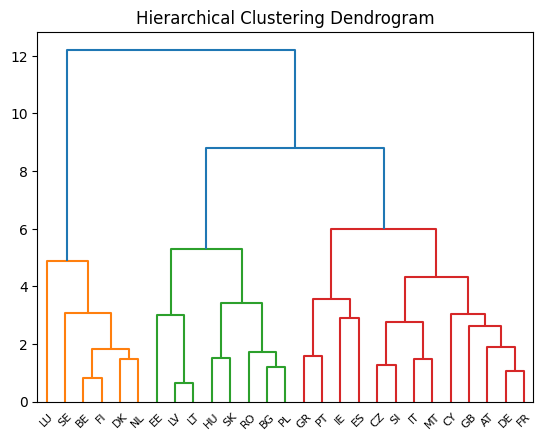

In [16]:
plt.title("Hierarchical Clustering Dendrogram")
# plot the whole tree
plot_dendrogram(model_applied, labels = countries_ue['Pays'].values, leaf_font_size = 8)
#plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

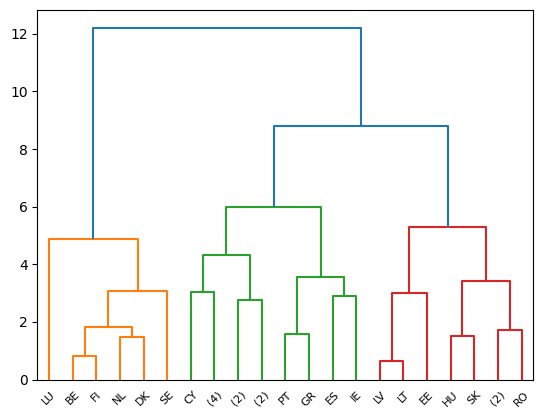

In [17]:
model_applied_scipy = linkage(X_stand, method = 'ward', metric = 'euclidean', optimal_ordering=True)
dn = dendrogram(model_applied_scipy, labels = countries_ue['Pays'].values, leaf_font_size = 8, truncate_mode='level', p=4)  #
plt.show()

In [18]:
model_applied_scipy

array([[12.        , 13.        ,  0.63926235,  2.        ],
       [ 0.        , 24.        ,  0.82676628,  2.        ],
       [ 9.        ,  4.        ,  1.0654538 ,  2.        ],
       [19.        ,  1.        ,  1.20355424,  2.        ],
       [22.        ,  2.        ,  1.26013283,  2.        ],
       [16.        , 10.        ,  1.46000042,  2.        ],
       [17.        ,  3.        ,  1.47301548,  2.        ],
       [15.        , 23.        ,  1.5026869 ,  2.        ],
       [20.        ,  7.        ,  1.59046919,  2.        ],
       [30.        , 21.        ,  1.7325149 ,  3.        ],
       [28.        , 33.        ,  1.83713464,  4.        ],
       [29.        , 18.        ,  1.90017585,  3.        ],
       [26.        , 38.        ,  2.63517647,  4.        ],
       [31.        , 32.        ,  2.75033966,  4.        ],
       [ 8.        ,  6.        ,  2.88787896,  2.        ],
       [27.        ,  5.        ,  3.00510438,  3.        ],
       [11.        , 39.

In [19]:
countries_ue.iloc[[12,13]]

,Pays,PIB,Dep_pub,Rev_net,Esp_vie,Chomage,Education,Gini,Securite,Adhesion,OCDE,Localisation,Rating
12,LV,8100.0,3757.0,12.8,73.7,19.8,25.3,36.1,25.2,2004,Non-OCDE,Est,5
13,LT,8400.0,3428.8,12.8,73.5,17.8,28.1,36.9,22.9,2004,Non-OCDE,Est,4


In [20]:
X_stand[12:14]

array([[-1.01120942, -1.03661115, -0.89126536, -1.77541103,  2.21378587,
         0.19761528,  1.70815334, -0.78520062],
       [-0.99164697, -1.0786055 , -0.89126536, -1.84359894,  1.75716083,
         0.57776069,  1.91648824, -0.85895794]])

In [37]:
countries_ue['cluster_5'] = fcluster(model_applied_scipy, t=5, criterion='maxclust')

In [23]:
countries_ue.groupby('cluster_5').agg({'Pays': ['count', 'min', 'max'],
                                       'PIB' : ['mean'],
                                       'Dep_pub' : ['mean'],
                                       'Rev_net' : ['mean'],
                                       'Esp_vie' : ['mean'],
                                       'Chomage' : ['mean'],
                                       'Education' : ['mean'],
                                       'Gini' : ['mean'],
                                       'Securite' : ['mean']}).round(2)

Pays               PIB   Dep_pub Rev_net Esp_vie Chomage Education  \
          count min max      mean      mean    mean    mean    mean      mean   
cluster_5                                                                       
1             6  BE  SE  43300.00  21956.78   23.62   80.53    6.95     30.93   
2             9  AT  SI  23900.00  11891.43   17.43   80.68    7.26     21.33   
3             4  ES  PT  23400.00  12973.80   11.12   80.92   14.60     22.78   
4             3  EE  LV   9066.67   3844.80   15.50   74.40   18.17     29.17   
5             5  BG  SK   8340.00   3597.08   14.14   74.86   10.58     17.52   

            Gini Securite  
            mean     mean  
cluster_5                  
1          26.07    92.55  
2          28.40    48.16  
3          33.42    37.02  
4          34.77    28.07  
5          29.52    24.10

In [24]:
countries_ue.head()

,Pays,PIB,Dep_pub,Rev_net,Esp_vie,Chomage,Education,Gini,Securite,Adhesion,OCDE,Localisation,Rating,cluster_5
0,BE,32700.0,17187.5,20.8,80.3,8.3,30.0,26.6,96.3,1957,OCDE,Ouest,2,1
1,BG,4800.0,1790.8,15.1,73.8,10.3,20.7,33.2,18.3,2007,Non-OCDE,Est,4,5
2,CZ,14300.0,6261.6,16.6,77.7,7.3,15.3,24.9,31.7,2004,Non-OCDE,Est,3,2
3,DK,42500.0,24562.8,26.7,79.3,7.5,29.5,26.9,88.9,1973,OCDE,Nord,1,1
4,DE,30500.0,14503.3,17.2,80.5,7.1,24.3,29.3,74.0,1957,OCDE,Ouest,1,2


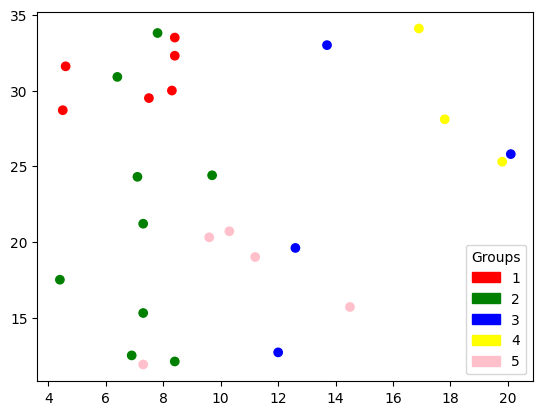

In [26]:
import matplotlib.patches as mpatches
color_map = {1: 'red', 2: 'green', 3: 'blue', 4 : 'yellow', 5 : 'pink' }
colors = [color_map[cat] for cat in countries_ue['cluster_5']]

# Plot
plt.scatter(countries_ue['Chomage'], countries_ue['Education'], c=colors)

# Create legend
patches = [mpatches.Patch(color=color, label=cat)
           for cat, color in color_map.items()]
plt.legend(handles=patches, title='Groups', loc = 'lower right')
plt.show()